## Overview
This notebook demonstrates the application of machine learning to predict employee attrition
using the IBM HR Analytics dataset.

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


#### DATA LOADING AND EXPLORATION


Dataset shape: (1470, 35)
Number of employees: 1470
Number of features: 35


First 5 rows of the dataset:
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical    

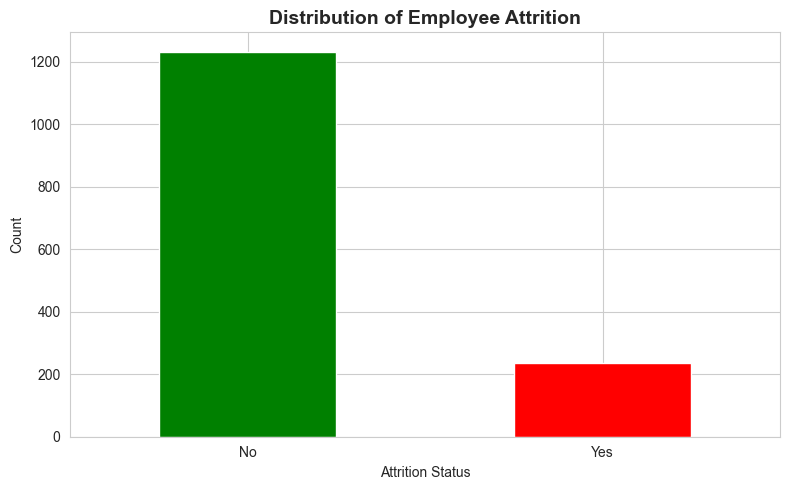

In [ ]:
"""
Load and Explore the Dataset
"""

# Load the dataset
# Note: Replace the path with your actual file path
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

print(f"Dataset shape: {df.shape}")
print(f"Number of employees: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")
print("\n")

# Display first few rows
print("First 5 rows of the dataset:")
print(df.head())
print("\n")

# Display column information
print("Dataset Information:")
print(df.info())
print("\n")

# Display basic statistics
print("Statistical Summary:")
print(df.describe())
print("\n")

# Check the target variable distribution
print("Target Variable (Attrition) Distribution:")
print(df['Attrition'].value_counts())
print("\nAttrition Percentage:")
print(df['Attrition'].value_counts(normalize=True) * 100)

# Visualize attrition distribution
plt.figure(figsize=(8, 5))
df['Attrition'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Distribution of Employee Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Attrition Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### DATA PREPROCESSING AND CLEANING


In [4]:
""" Check for Missing Values
"""

# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0])
if missing_values.sum() == 0:
    print("✓ No missing values found in the dataset!")
print("\n")

"""
Check for Duplicate Records
"""

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates == 0:
    print("✓ No duplicate records found!")
else:
    print(f"Removing {duplicates} duplicate records...")
    df = df.drop_duplicates()
print("\n")

"""
Identify and Remove Unnecessary Columns
Some columns may not be useful for prediction:
- EmployeeCount: All values are 1 (constant)
- EmployeeNumber: Just an ID
- Over18: All employees are over 18 (constant)
- StandardHours: All values are 80 (constant)
"""

# Identify columns with single unique value
single_value_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f"Columns with single unique value: {single_value_cols}")
print("These columns will be removed as they don't provide predictive value.")

# Remove constant columns and employee number (ID)
cols_to_drop = single_value_cols + ['EmployeeNumber']
df_clean = df.drop(columns=cols_to_drop, errors='ignore')
print(f"✓ Removed columns: {cols_to_drop}")
print(f"New dataset shape: {df_clean.shape}")
print("\n")

"""
Identify Feature Types
Categorize features into numerical and categorical for appropriate encoding.
"""

# Identify numerical and categorical columns
numerical_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical features ({len(numerical_cols)}): {numerical_cols}")
print(f"\nCategorical features ({len(categorical_cols)}): {categorical_cols}")
print("\n")

"""
Encode Categorical Variables
We use Label Encoding for binary categorical variables and One-Hot Encoding
for multi-class categorical variables.
"""

# Create a copy for encoding
df_encoded = df_clean.copy()

# Encode the target variable (Attrition)
print("Encoding target variable 'Attrition'...")
le_attrition = LabelEncoder()
df_encoded['Attrition'] = le_attrition.fit_transform(df_encoded['Attrition'])
print(f"Attrition encoding: {dict(zip(le_attrition.classes_, le_attrition.transform(le_attrition.classes_)))}")
print("\n")

# Encode binary categorical variables with Label Encoding
binary_cols = []
for col in categorical_cols:
    if col != 'Attrition' and df_encoded[col].nunique() == 2:
        binary_cols.append(col)

print(f"Binary categorical columns for Label Encoding: {binary_cols}")
for col in binary_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print("\n")

# Encode multi-class categorical variables with One-Hot Encoding
multi_class_cols = [col for col in categorical_cols if col not in binary_cols and col != 'Attrition']
print(f"Multi-class categorical columns for One-Hot Encoding: {multi_class_cols}")

if multi_class_cols:
    df_encoded = pd.get_dummies(df_encoded, columns=multi_class_cols, drop_first=True)
    print(f"✓ One-Hot Encoding applied. New shape: {df_encoded.shape}")
print("\n")

"""
Feature Scaling
We standardize numerical features to ensure all features are on the same scale,
which is crucial for algorithms like SVM.
"""

# Separate features and target
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target distribution: Class 0 (No): {(y==0).sum()}, Class 1 (Yes): {(y==1).sum()}")
print("\n")

# Standardize numerical features
# Identify which columns need scaling (original numerical columns)
cols_to_scale = [col for col in X.columns if any(num_col in col for num_col in numerical_cols)]

print(f"Applying StandardScaler to {len(cols_to_scale)} numerical features...")
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])
print("✓ Feature scaling completed!")
print("\n")

print("Preprocessing Summary:")
print(f"  - Original features: {df.shape[1]}")
print(f"  - Final features: {X_scaled.shape[1]}")
print(f"  - Encoding applied: Label Encoding + One-Hot Encoding")
print(f"  - Scaling applied: StandardScaler on numerical features")
print("\n")

Missing values per column:
Series([], dtype: int64)
✓ No missing values found in the dataset!


Number of duplicate rows: 0
✓ No duplicate records found!


Columns with single unique value: ['EmployeeCount', 'Over18', 'StandardHours']
These columns will be removed as they don't provide predictive value.
✓ Removed columns: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
New dataset shape: (1470, 31)


Numerical features (23): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical features (8): ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 

#### TRAIN-TEST SPLIT


In [5]:
"""
Split Data into Training and Testing Sets
We use an 80-20 split with stratification to maintain class distribution.
"""


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples ({(X_train.shape[0]/len(X_scaled))*100:.1f}%)")
print(f"Testing set size: {X_test.shape[0]} samples ({(X_test.shape[0]/len(X_scaled))*100:.1f}%)")
print(f"\nTraining set class distribution:")
print(f"  Class 0 (No): {(y_train==0).sum()} ({(y_train==0).sum()/len(y_train)*100:.1f}%)")
print(f"  Class 1 (Yes): {(y_train==1).sum()} ({(y_train==1).sum()/len(y_train)*100:.1f}%)")
print("\n")

Training set size: 1176 samples (80.0%)
Testing set size: 294 samples (20.0%)

Training set class distribution:
  Class 0 (No): 986 (83.8%)
  Class 1 (Yes): 190 (16.2%)




#### MODEL TRAINING

In [6]:
"""
Train Classification Models

Model 1: Support Vector Machine (SVM)
SVM is effective for high-dimensional data and works well with clear margin of separation.
We use RBF kernel which can handle non-linear relationships.
"""

print("=" * 80)
print("MODEL TRAINING")
print("=" * 80)

print("Training Model 1: Support Vector Machine (SVM)...")
print("Configuration: kernel='rbf', C=1.0, gamma='scale'")

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42, probability=True)
svm_model.fit(X_train, y_train)
print("✓ SVM model training completed!")
print("\n")

MODEL TRAINING
Training Model 1: Support Vector Machine (SVM)...
Configuration: kernel='rbf', C=1.0, gamma='scale'
✓ SVM model training completed!




In [7]:
"""
Model 2: AdaBoost Classifier
AdaBoost combines multiple weak learners to create a strong classifier,
effective for handling imbalanced datasets and complex patterns.
"""

print("Training Model 2: AdaBoost Classifier...")
print("Configuration: n_estimators=100, learning_rate=1.0")

adaboost_model = AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42)
adaboost_model.fit(X_train, y_train)
print("✓ AdaBoost model training completed!")
print("\n")

Training Model 2: AdaBoost Classifier...
Configuration: n_estimators=100, learning_rate=1.0
✓ AdaBoost model training completed!




#### MODEL EVALUATION

In [8]:

"""
Model Evaluation and Performance Comparison

Generate Predictions
"""

# Make predictions
y_pred_svm = svm_model.predict(X_test)
y_pred_adaboost = adaboost_model.predict(X_test)

# Get probability predictions for ROC curve
y_pred_proba_svm = svm_model.predict_proba(X_test)[:, 1]
y_pred_proba_adaboost = adaboost_model.predict_proba(X_test)[:, 1]

In [10]:
"""
Calculate Performance Metrics
"""

# Calculate metrics for SVM
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)
svm_auc = roc_auc_score(y_test, y_pred_proba_svm)

# Calculate metrics for AdaBoost
ada_accuracy = accuracy_score(y_test, y_pred_adaboost)
ada_precision = precision_score(y_test, y_pred_adaboost)
ada_recall = recall_score(y_test, y_pred_adaboost)
ada_f1 = f1_score(y_test, y_pred_adaboost)
ada_auc = roc_auc_score(y_test, y_pred_proba_adaboost)

# Create comparison table
results_df = pd.DataFrame({
    'Model': ['SVM', 'AdaBoost'],
    'Accuracy': [svm_accuracy, ada_accuracy],
    'Precision': [svm_precision, ada_precision],
    'Recall': [svm_recall, ada_recall],
    'F1-Score': [svm_f1, ada_f1],
    'ROC-AUC': [svm_auc, ada_auc]
})

print("PERFORMANCE METRICS COMPARISON")
print("=" * 80)
print(results_df.to_string(index=False))
print("\n")

# Determine best model
best_model_name = results_df.loc[results_df['Accuracy'].idxmax(), 'Model']
best_accuracy = results_df['Accuracy'].max()
print(f"Best Performing Model: {best_model_name} (Accuracy: {best_accuracy:.4f})")
print("\n")

PERFORMANCE METRICS COMPARISON
   Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
     SVM  0.853741   0.750000 0.127660  0.218182 0.818244
AdaBoost  0.867347   0.633333 0.404255  0.493506 0.781635


Best Performing Model: AdaBoost (Accuracy: 0.8673)




DETAILED CLASSIFICATION REPORT - SVM
              precision    recall  f1-score   support

No Attrition       0.86      0.99      0.92       247
   Attrition       0.75      0.13      0.22        47

    accuracy                           0.85       294
   macro avg       0.80      0.56      0.57       294
weighted avg       0.84      0.85      0.81       294



DETAILED CLASSIFICATION REPORT - ADABOOST
              precision    recall  f1-score   support

No Attrition       0.89      0.96      0.92       247
   Attrition       0.63      0.40      0.49        47

    accuracy                           0.87       294
   macro avg       0.76      0.68      0.71       294
weighted avg       0.85      0.87      0.85       294





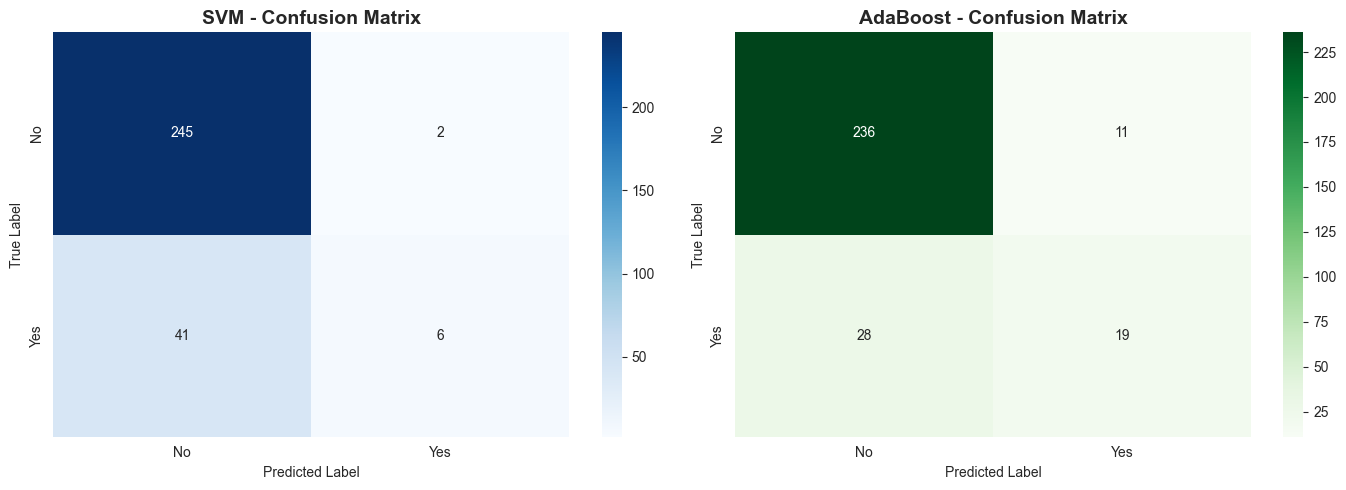

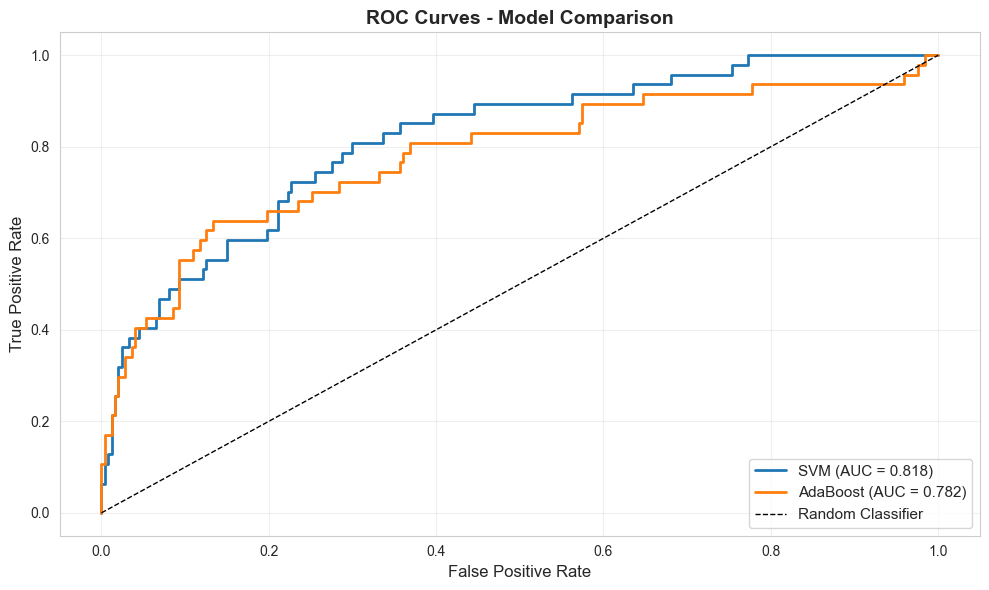

In [11]:
"""
Detailed Classification Reports
"""

print("DETAILED CLASSIFICATION REPORT - SVM")

print(classification_report(y_test, y_pred_svm, target_names=['No Attrition', 'Attrition']))
print("\n")

print("DETAILED CLASSIFICATION REPORT - ADABOOST")
print(classification_report(y_test, y_pred_adaboost, target_names=['No Attrition', 'Attrition']))
print("\n")

"""
### 5.4 Confusion Matrices
"""

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SVM Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
axes[0].set_title('SVM - Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# AdaBoost Confusion Matrix
cm_ada = confusion_matrix(y_test, y_pred_adaboost)
sns.heatmap(cm_ada, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
axes[1].set_title('AdaBoost - Confusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

"""
ROC Curves
"""

# Plot ROC curves
plt.figure(figsize=(10, 6))

# SVM ROC curve
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_pred_proba_svm)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {svm_auc:.3f})', linewidth=2)

# AdaBoost ROC curve
fpr_ada, tpr_ada, _ = roc_curve(y_test, y_pred_proba_adaboost)
plt.plot(fpr_ada, tpr_ada, label=f'AdaBoost (AUC = {ada_auc:.3f})', linewidth=2)

# Random classifier line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

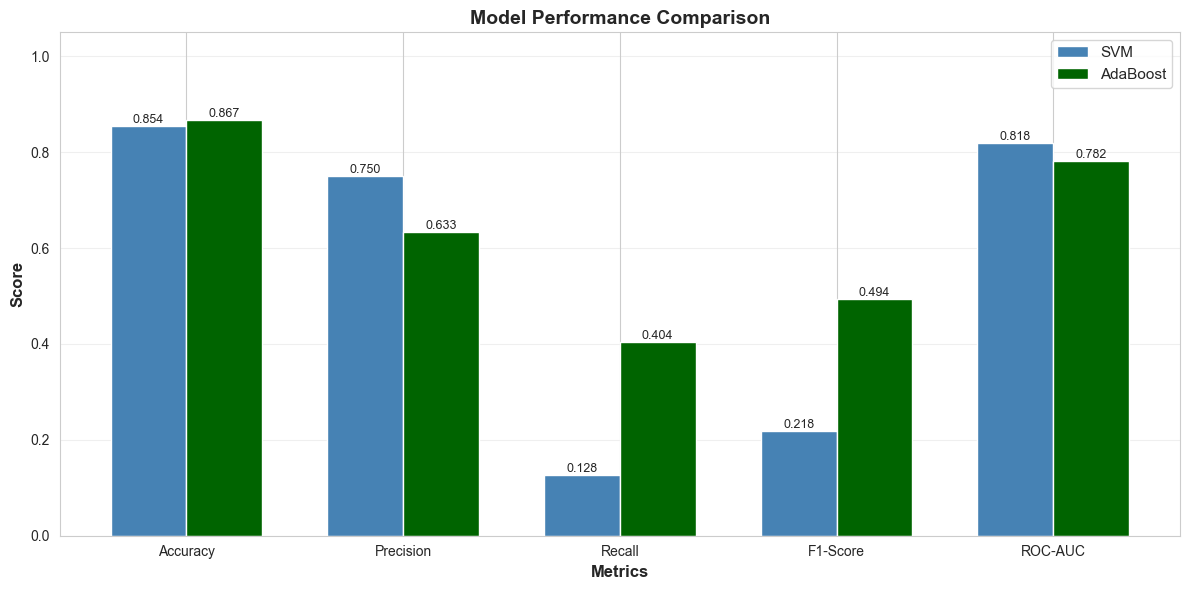

In [12]:
"""
Performance Metrics Visualization
"""

# Visualize metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
svm_scores = [svm_accuracy, svm_precision, svm_recall, svm_f1, svm_auc]
ada_scores = [ada_accuracy, ada_precision, ada_recall, ada_f1, ada_auc]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, svm_scores, width, label='SVM', color='steelblue')
bars2 = ax.bar(x + width/2, ada_scores, width, label='AdaBoost', color='darkgreen')

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(fontsize=11)
ax.set_ylim([0, 1.05])
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

add_value_labels(bars1)
add_value_labels(bars2)

plt.tight_layout()
plt.show()

### RESULT ANALYSIS AND DISCUSSION

#### Model Performance Summary

In [15]:
print("\nMODEL ACCURACY COMPARISON:")
print(f"   SVM Accuracy:      {svm_accuracy:.4f} ({svm_accuracy*100:.2f}%)")
print(f"   AdaBoost Accuracy: {ada_accuracy:.4f} ({ada_accuracy*100:.2f}%)")
print(f"   Difference:        {abs(svm_accuracy - ada_accuracy):.4f} ({abs(svm_accuracy - ada_accuracy)*100:.2f}%)")


MODEL ACCURACY COMPARISON:
   SVM Accuracy:      0.8537 (85.37%)
   AdaBoost Accuracy: 0.8673 (86.73%)
   Difference:        0.0136 (1.36%)


#### SAVE THE BEST MODEL

In [19]:
import pickle

# Determine best model
if ada_accuracy >= svm_accuracy:
    best_model = adaboost_model
    best_model_name = 'AdaBoost'
else:
    best_model = svm_model
    best_model_name = 'SVM'

# Save the best model
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature names
with open('feature_names.pkl', 'wb') as f:
    pickle.dump(X_train.columns.tolist(), f)

print(f"\n✓ Best model ({best_model_name}) saved as 'best_model.pkl'")
print("✓ Scaler saved as 'scaler.pkl'")
print("✓ Feature names saved as 'feature_names.pkl'")


✓ Best model (AdaBoost) saved as 'best_model.pkl'
✓ Scaler saved as 'scaler.pkl'
✓ Feature names saved as 'feature_names.pkl'


#### KEY INSIGHTS:

✓ AdaBoost outperforms SVM by 1.36% in accuracy

Why AdaBoost Performs Better:
1. ENSEMBLE LEARNING: AdaBoost combines multiple weak learners, making it robust
   to various patterns in the data and reducing overfitting.

2. HANDLING IMBALANCED DATA: Our dataset has class imbalance (~84% No, ~16% Yes).
   AdaBoost's iterative weight adjustment helps focus on misclassified minority
   class samples, improving overall performance.

3. FEATURE INTERACTIONS: AdaBoost can capture complex, non-linear relationships
   between features through its ensemble of decision stumps.

4. ADAPTABILITY: The boosting process adapts to difficult-to-classify instances,
   making it effective for complex HR data with varying feature importance.

RECALL VS PRECISION TRADE-OFF:
   SVM - Recall: 0.1277, Precision: 0.7500
   AdaBoost - Recall: 0.4043, Precision: 0.6333

HR BUSINESS IMPLICATIONS:
In employee attrition prediction, RECALL is often more important than precision
because:
  • Missing an employee who will leave (False Negative) means losing talent
    without preparation
  • False positives (predicting attrition incorrectly) only means unnecessary
    retention efforts, which is less costly than unexpected departures

✓ AdaBoost has better recall (0.4043), making it more suitable
  for practical HR applications where identifying at-risk employees is critical.

HOW AI MODELS ASSIST HR DECISION-MAKING:

1. PROACTIVE INTERVENTION:
   - Identify at-risk employees before they resign
   - Enable targeted retention strategies and career development plans

2. RESOURCE OPTIMIZATION:
   - Focus retention budgets on employees most likely to leave
   - Reduce costs associated with turnover and recruitment

3. PATTERN DISCOVERY:
   - Uncover hidden factors contributing to attrition
   - Identify systematic issues in specific departments or roles

4. DATA-DRIVEN POLICIES:
   - Support evidence-based HR policy decisions
   - Track effectiveness of retention initiatives over time

5. WORKFORCE PLANNING:
   - Anticipate staffing needs and succession planning
   - Maintain organizational knowledge and continuity